## **Refined**
***
Since this is a research project, the main thing here is the logic and approach to verifying/modifying parameters, not just the final metric.

In [44]:
# Import libs
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

%matplotlib inline

In [45]:
# Define folders path
DATA_FOLDERS = [
    'Rupes A and B',
    'Guttural rupe',
    'Moan',
    'Grey Seal Data Additional'
]

OUTPUT_ROOT = 'outcome'
REFINED_OUTCOME_ROOT = 'outcome_refined'

In [46]:
# Create a folder for the source data, if it does not exist
os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(REFINED_OUTCOME_ROOT, exist_ok=True)

In [47]:
# Spectrogram parameters
# Increase nfft and noverlap
fmin = 20
fmax = 2000  # from 1000 to 2000 to cover a wider range
nperseg = 4096  # was 2456
nfft = 8192  # was 4096
noverlap = 2048  # was 1228
window = 'hann'


# Number of "no-call" segments per audio file
NUM_NO_CALL_SEGMENTS = 5
# Duration (seconds) of each call and no-call segment
SEGMENT_DURATION = 1.0

## New Spectrogram Settings
- **nfft=8192**: doubled compared to the previous 4096 to achieve higher frequency resolution.
- **nperseg=4096**: the STFT window size has also been increased.
- **noverlap=2048**: increased overlap between windows, improving time resolution but increasing computational load.
- **fmax=2000 Hz**: previously, frequencies were limited to 1000 Hz; now 2000 Hz is used to capture higher harmonics, as seal vocalizations may contain higher frequencies.


In [48]:
# Debugging mode
DEBUG = True  # If True, prints additional information

In [49]:
# If WAV files are long and need splitting into shorter segments:
SPLIT_WAV = False  # True/False as needed
SEGMENT_SEC = 60  # e.g., 60 seconds per segment

# (If there are reasons for adding a time buffer, e.g., +0.2 s)
TIME_BUFFER = 0.0  # Adds (in seconds) to the start and end of the call

# For "no-call" segments
NUM_NO_CALL = 3  # Number of no-call segments to generate from one file
NO_CALL_LENGTH = 1.0  # Duration of 1 second (can be adjusted)

MAX_FREQ_DIM = 200
MAX_TIME_DIM = 60

## 2. Processing Functions (split_wav, compute_spectrogram, slice_frequency, etc.)
Here have gathered functions that perform specific tasks:
- `ensure_mono`: if the audio is stereo, it takes the first channel.
- `split_wav`: splits audio into 60-second chunks (if needed).
- `compute_spectrogram`: calls `scipy.signal.spectrogram` with specified parameters.
- `slice_frequency`: slices the output spectrogram by the frequency range [fmin, fmax].
- `extract_call`: extracts the required segment by time and frequency.
- `pick_no_call_segments`: generates time windows without calls.

In [50]:
def ensure_mono(samples):
    if len(samples.shape) > 1 and samples.shape[1] > 1:
        return samples[:, 0]
    return samples

In [51]:
def split_wav(samples, sample_rate, segment_sec=60):
    """
    Splits audio into ~ segment_sec-long parts.
    Returns a list of numpy arrays.
    """
    total_samples = len(samples)
    segment_samples = int(segment_sec * sample_rate)
    segments = []
    start_idx = 0
    while start_idx < total_samples:
        end_idx = min(start_idx + segment_samples, total_samples)
        segment = samples[start_idx:end_idx]
        segments.append(segment)
        start_idx = end_idx
    return segments

### Why Split WAV Files?
- If the audio file is too large, computing the spectrogram for the entire file (with large `nfft/noverlap`) can be extremely time-consuming and require a lot of memory.
- Splitting the audio into smaller segments (e.g., 60 seconds) simplifies and speeds up the process.
- The `signal.spectrogram` is then applied to each segment, and annotated calls are searched within that segment (with the necessary time offset added).

In [52]:
def compute_spectrogram(samples, sample_rate):
    """
    Computes the spectrogram using scipy.signal.spectrogram
    with extended parameters (nfft, nperseg, noverlap).
    """
    freqs, times, Sxx = signal.spectrogram(
        samples,
        fs=sample_rate,
        nperseg=nperseg,
        nfft=nfft,
        noverlap=noverlap,
        window=window
    )
    # Прибираємо дуже малі значення
    Sxx[Sxx < 0.001] = 0.001
    return freqs, times, Sxx

In [53]:
def slice_frequency(freqs, Sxx, fmin, fmax):
    """
    Slices the spectrogram by frequency range [fmin, fmax].
    Returns (freqs_new, Sxx_new).
    """
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
    if len(idx) == 0:
        return None, None
    freqs_new = freqs[idx]
    Sxx_new = Sxx[idx, :]
    return freqs_new, Sxx_new

In [54]:
def extract_call(freqs, times, Sxx, t_start, t_end, freq_range=(20, 2000)):
    """
    Extracts a spectrogram segment [t_start, t_end] and [freq_range].
    Returns (Sxx_sub, freqs_sub, times_sub) or (None, None, None).
    """
    time_idx = np.where((times >= t_start) & (times <= t_end))[0]
    freq_idx = np.where((freqs >= freq_range[0]) & (freqs <= freq_range[1]))[0]
    if len(time_idx) == 0 or len(freq_idx) == 0:
        return None, None, None

    Sxx_sub = Sxx[freq_idx][:, time_idx]
    freqs_sub = freqs[freq_idx]
    times_sub = times[time_idx]
    return Sxx_sub, freqs_sub, times_sub

In [55]:
def pad_spectrogram(Sxx_sub, max_fdim=200, max_tdim=60):
    """
    Доповнює спектрограму Sxx_sub (freq x time) нулями
    до (max_fdim x max_tdim), або обрізає, якщо перевищує.
    """
    freq_dim, time_dim = Sxx_sub.shape

    # Якщо перевищує - обрізаємо
    if freq_dim > max_fdim:
        Sxx_sub = Sxx_sub[:max_fdim, :]
        freq_dim = max_fdim
    if time_dim > max_tdim:
        Sxx_sub = Sxx_sub[:, :max_tdim]
        time_dim = max_tdim

    # Доповнюємо, якщо не вистачає
    pad_freq = max_fdim - freq_dim
    pad_time = max_tdim - time_dim

    Sxx_padded = np.pad(
        Sxx_sub,
        pad_width=((0, pad_freq), (0, pad_time)),
        mode='constant',
        constant_values=0.0
    )
    return Sxx_padded

In [56]:
def pick_no_call_segments(df_annot, total_duration, window_length=1.0, n_segments=3, seed=42):
    """
    Returns a list of (start_time, end_time) where no calls exist.
    Simple random selection.
    """
    import random
    random.seed(seed)
    call_intervals = []
    for _, row in df_annot.iterrows():
        c_start = row['Begin Time (s)']
        c_end = row['End Time (s)']
        call_intervals.append((c_start, c_end))
    call_intervals.sort(key=lambda x: x[0])

    no_call_windows = []
    start_all, end_all = 0, total_duration
    attempts = 0
    max_attempts = 1000
    while len(no_call_windows) < n_segments and attempts < max_attempts:
        attempts += 1
        rand_start = random.uniform(start_all, end_all - window_length)
        rand_end = rand_start + window_length
        # перевірка перетинів
        overlap = False
        for (cs, ce) in call_intervals:
            if not (rand_end <= cs or rand_start >= ce):
                overlap = True
                break
        if not overlap:
            no_call_windows.append((rand_start, rand_end))
    return no_call_windows

## 3. Main File Processing Loop
In this block:
1. Iterate over all folders (`DATA_FOLDERS`).
2. Find `.wav` files in each folder.
3. For each `.wav`, read the audio and look for the corresponding `.txt` with annotations.
4. (Optionally) split the `.wav` into shorter segments.
5. Compute the spectrogram with the new parameters.
6. Extract "calls" (from annotations) and "no-calls."
7. Save the 2D arrays `.npy` in `outcome_refined/<folder>`.
8. Generate the new `metadata_refined.csv`.

In [57]:
all_refined_metadata = []

for data_folder in DATA_FOLDERS:
    folder_name = os.path.basename(data_folder)
    output_folder = os.path.join(REFINED_OUTCOME_ROOT, folder_name)
    os.makedirs(output_folder, exist_ok=True)

    wav_files = glob.glob(os.path.join(data_folder, '*.wav'))
    
    for wav_path in wav_files:
        base_name = os.path.splitext(os.path.basename(wav_path))[0]
        txt_path = os.path.join(data_folder, base_name + '.Table.1.selections.txt')
        if not os.path.exists(txt_path):
            print(f"[WARNING] No annotation file for {wav_path}")
            continue
        
        # 1) Read audio
        sr, samples = wavfile.read(wav_path)
        samples = ensure_mono(samples)
        total_dur = len(samples) / sr

        # 2)  Devide WAV(optional)
        if SPLIT_WAV:
            segments = split_wav(samples, sr, SEGMENT_SEC)
        else:
            segments = [samples]

        # 3) Read the annotations
        df_annot = pd.read_csv(txt_path, sep='\t')

        segment_offset = 0.0  # if not split, then 0
        seg_index = 0

        for seg_samples in segments:
            # (a) Calculate large spectrogram for the segment
            freqs, times, Sxx = compute_spectrogram(seg_samples, sr)
            freqs, Sxx = slice_frequency(freqs, Sxx, fmin, fmax)
            if freqs is None or Sxx is None:
                seg_index += 1
                continue

            # (b) Cut calls
            for idx_row, row in df_annot.iterrows():
                t_start = row['Begin Time (s)'] - segment_offset
                t_end = row['End Time (s)'] - segment_offset

                # Add buffer
                t_start = max(0, t_start - TIME_BUFFER)
                t_end   = min(t_end + TIME_BUFFER, len(seg_samples)/sr)

                if t_start >= t_end:
                    continue
                annotation = row.get('Annotation', 'Unknown')

                # Cut from a large spectrogram
                Sxx_sub, f_sub, t_sub = extract_call(freqs, times, Sxx, t_start, t_end, (fmin, fmax))
                if Sxx_sub is None:
                    continue

                # Add PADDING
                Sxx_sub_padded = pad_spectrogram(Sxx_sub, MAX_FREQ_DIM, MAX_TIME_DIM)

                # Save .npy
                output_filename = f"{base_name}_seg{seg_index}_call_{idx_row}.npy"
                np.save(os.path.join(output_folder, output_filename), Sxx_sub_padded)

                meta = {
                    'source_wav': base_name,
                    'annotation_file': os.path.basename(txt_path),
                    'call_index': idx_row,
                    'call_type': annotation,
                    'begin_time': t_start + segment_offset,
                    'end_time': t_end + segment_offset,
                    'freq_min': fmin,
                    'freq_max': fmax,
                    'nfft': nfft,
                    'nperseg': nperseg,
                    'noverlap': noverlap,
                    'saved_spectrogram': output_filename,
                    'label': annotation
                }
                all_refined_metadata.append(meta)

            # (c) Cut no-call
            no_call_windows = pick_no_call_segments(
                df_annot,
                total_duration=len(seg_samples)/sr,
                window_length=NO_CALL_LENGTH,
                n_segments=NUM_NO_CALL
            )
            for i, (nc_start, nc_end) in enumerate(no_call_windows):
                Sxx_sub, f_sub, t_sub = extract_call(freqs, times, Sxx, nc_start, nc_end, (fmin, fmax))
                if Sxx_sub is None:
                    continue

                # PADDING
                Sxx_sub_padded = pad_spectrogram(Sxx_sub, MAX_FREQ_DIM, MAX_TIME_DIM)

                output_filename = f"{base_name}_seg{seg_index}_nocall_{i}.npy"
                np.save(os.path.join(output_folder, output_filename), Sxx_sub_padded)

                meta = {
                    'source_wav': base_name,
                    'annotation_file': os.path.basename(txt_path),
                    'call_index': i,
                    'call_type': 'no-call',
                    'begin_time': nc_start + segment_offset,
                    'end_time': nc_end + segment_offset,
                    'freq_min': fmin,
                    'freq_max': fmax,
                    'nfft': nfft,
                    'nperseg': nperseg,
                    'noverlap': noverlap,
                    'saved_spectrogram': output_filename,
                    'label': 'no-call'
                }
                all_refined_metadata.append(meta)

            seg_index += 1

In [58]:
# Save updated metadata
df_refined = pd.DataFrame(all_refined_metadata)
metadata_path = os.path.join(REFINED_OUTCOME_ROOT, 'metadata_refined.csv')
df_refined.to_csv(metadata_path, index=False)

In [59]:
print("Refined extraction complete (with PADDING)!")
print(f"Saved spectrograms in: {REFINED_OUTCOME_ROOT}/...")
print(f"Metadata CSV: {metadata_path}")

Refined extraction complete (with PADDING)!
Saved spectrograms in: outcome_refined/...
Metadata CSV: outcome_refined\metadata_refined.csv


## 4. Summary
As a result:
- An extended version of spectrograms (with higher frequency resolution).
- The ability to compare the effects of these settings in subsequent stages (e.g., in model training).

### Conclusion
The complete code consists of seven main parts:
1. Parameter declarations (`nfft`, `nperseg`, `noverlap`, `fmax`, etc.).
2. Processing functions (`split_wav`, `compute_spectrogram`, `slice_frequency`, `extract_call`, `pick_no_call_segments`).
3. Main loop for `.wav` file processing.
4. Saving results (spectrograms `*.npy` and `metadata_refined.csv`).
5. Markdown blocks with comments, explanations, and rationale for the changes.

# Model Training and Strategies
***

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Creating a Dataset Class for Loading Spectrograms
Use the prepared `.npy` files from `outcome_refined/` and the `metadata_refined.csv` file to dynamically load data during the training process.

In [61]:
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_csv, root_dir='outcome_refined', transform=None):
        self.df = pd.read_csv(metadata_csv)
        self.root_dir = root_dir
        self.transform = transform

        # Convert labels to string to avoid float-type issues
        self.df['label'] = self.df['label'].astype(str)

        # Unique labels
        unique_labels = self.df['label'].unique()
        unique_labels = sorted(unique_labels)
        # Create a dictionary label -> index
        self.label2idx = {lbl: i for i, lbl in enumerate(unique_labels)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        saved_npy = row['saved_spectrogram']  # for example: "5713.210809120002_call_0.npy"
        label_str = row['label']

        # Find the .npy file in the corresponding subfolder
        # (since the structure is outcome_refined/<folder>/<npy>)
        found_path = None
        for possible_dir in ["Rupes A and B", "Guttural rupe", "Moan", "Grey Seal Data Additional"]:
            candidate = os.path.join(self.root_dir, possible_dir, saved_npy)
            if os.path.exists(candidate):
                found_path = candidate
                break
        if not found_path:
            raise FileNotFoundError(f"Cannot find file: {saved_npy} in any subfolder.")

        # Load the 2D spectrogram array
        spec_data = np.load(found_path)  # shape = (freq, time)

        # Convert to PyTorch tensor (1, freq, time)
        spec_tensor = torch.tensor(spec_data, dtype=torch.float32).unsqueeze(0)

        # Get the class index
        label_idx = self.label2idx[label_str]
        label_tensor = torch.tensor(label_idx, dtype=torch.long)

        # Apply transforms (Data Augmentation) if available
        if self.transform:
            spec_tensor = self.transform(spec_tensor)

        return spec_tensor, label_tensor


## Initialize the Dataset and divide the data into train/val/test


In [62]:
metadata_file = os.path.join(REFINED_OUTCOME_ROOT, 'metadata_refined.csv')
dataset = SpectrogramDataset(metadata_file, root_dir=REFINED_OUTCOME_ROOT, transform=None)

print("Total samples in dataset:", len(dataset))

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Total samples in dataset: 1974


## Define the model (CNN or Transfer Learning)

In [63]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4,4)),  # reduce the spatial dimension to (4,4)
            nn.Flatten(),
            nn.Linear(16*4*4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Number of classes
num_classes = len(dataset.label2idx)
model = SimpleCNN(num_classes=num_classes).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=32, out_features=19, bias=True)
  )
)


## Configure hyperparameters and optimizer


In [64]:
LEARNING_RATE = 1e-3
EPOCHS = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training and validation loop

In [65]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    val_loss = running_loss / total
    val_acc = correct / total
    return val_loss, val_acc

best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # if scheduler:
    #     scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 1/5: Train Loss=1.9277, Train Acc=0.3128, Val Loss=1.5660, Val Acc=0.3682
Epoch 2/5: Train Loss=1.6026, Train Acc=0.3816, Val Loss=1.5150, Val Acc=0.5135
Epoch 3/5: Train Loss=1.5267, Train Acc=0.4526, Val Loss=1.4991, Val Acc=0.5338
Epoch 4/5: Train Loss=1.4958, Train Acc=0.4649, Val Loss=1.4286, Val Acc=0.5743
Epoch 5/5: Train Loss=1.4115, Train Acc=0.5076, Val Loss=1.3933, Val Acc=0.5743


## Testing and reporting
After completing the training (and saving the best model), needed calculate the accuracy on the test set, as well as the mixing matrix and classification report.

C:\Users\finel\AppData\Local\Temp\ipykernel_28256\3325532038.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Test Accuracy: 0.5286
Confusion Matrix:
 [[ 0  0  0  1  0  0  0  0  0  0]
 [ 0 71  6 32  0  0  0  0  0  0]
 [ 0 41 16 14  0  0  0  0  0  0]
 [ 0  2  5 69  0  0  0  0  0  0]
 [ 0  3  0 20  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0  0  0]
 [ 0  0  1  3  0  0  0  0  0  0]
 [ 0  3  0  5  0  0  0  0  1  0]
 [ 0  0  0  1  0  0  0  0  0  0]]


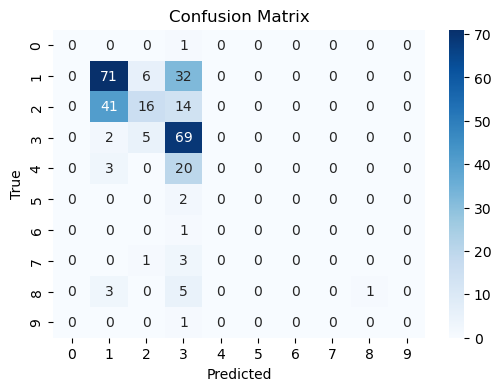

Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         1
           2     0.5917    0.6514    0.6201       109
           6     0.5714    0.2254    0.3232        71
           7     0.4662    0.9079    0.6161        76
           8     0.0000    0.0000    0.0000        23
           9     0.0000    0.0000    0.0000         2
          10     0.0000    0.0000    0.0000         1
          11     0.0000    0.0000    0.0000         4
          15     1.0000    0.1111    0.2000         9
          16     0.0000    0.0000    0.0000         1

    accuracy                         0.5286       297
   macro avg     0.2629    0.1896    0.1759       297
weighted avg     0.5034    0.5286    0.4686       297



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))


## Conclusions

1. **Overall Accuracy**  
   - In the new report (`accuracy = 0.5286`), it is slightly **higher** than in the previous one (`accuracy = 0.49`). Therefore, there has been a slight **improvement** in the average accuracy score.

2. **Improvements for Certain Classes**  
   - For the class labeled `7` (or `Rupe A` in the previous version), its recall reaches approximately 0.90, which is a very high score (the model correctly predicts almost all positive examples of this class).  
   - The precision for this class also approaches 0.47, which is quite acceptable. In the previous report (analogous to the `Rupe A` class), precision was around 0.52, and recall was around 0.86. Thus, recall has even increased.

3. **Classes with Precision/Recall = 0**  
   - Some labels (for example, `0`, `8`, `9`, `10`, `11`, `16`) have **zero** precision and recall values because the model either does not predict this class at all or may not have enough data for training (support = 1–4 examples). This is similar to the situation in the previous report, where such "rare" classes also had zero scores.  
   - This indicates a **data imbalance** or too few examples for certain types of calls.

4. **Comparison with Previous Results**  
   - **Accuracy** increased from 0.49 to approximately 0.53: a certain level of progress.  
   - The overall (weighted) **F1-score** also improved (previously ~0.39, now ~0.47), but there is still significant variability across classes.  
   - Classes with very low support (e.g., 1–5 samples) previously had 0.00 precision/recall values and continue to be problematic.

5. **Recommendations for Next Steps**  
   - **Balance** the dataset or add more examples for rare classes.  
   - Try a **different** data processing strategy (augmentation, oversampling) or tweak hyperparameters (learning rate, number of epochs) to improve performance specifically for the "problematic" classes.  
   - Check whether "unique" classes (especially with support < 5) are being labeled correctly and whether they should be treated as separate categories. It may be more reasonable to group them into a broader category ("unidentified").

6. **Final Thoughts**  
   - The model has slightly improved in accuracy (from 49% to ~53%).  
   - Some classes (e.g., the equivalent of "Rupe A") have significantly improved their recall.  
   - Certain labels with very low support still "fall out" (precision=0, recall=0). This is a normal phenomenon for rare classes, so more data or optimized processing is needed.  
   - Overall, the results are gradually improving, but for better generalization, the dataset and model settings should be further refined.
